# Llama 3.1 8B Instruct as a difficulty classifier (in-context learning)

No training: the model gets instructions (and optionally a few solved examples) in its prompt and has to answer
Easy, Medium or Hard. Runs locally on Apple Silicon with [MLX](https://github.com/ml-explore/mlx) in 4-bit
(~5 GB of memory).

**No text generation.** Instead of letting the model write an answer and searching it for "easy", we show it
the prompt and read the probability it gives to the next word being `Easy`, `Medium` or `Hard`:

```
[system: rules]  [user: example problem]  [assistant: Medium]  …  [user: new problem]  [assistant: ▢]
                                                                                              │
                                                    P(Easy) = 0.21, P(Medium) = 0.58, P(Hard) = 0.21
```

One forward pass per problem, nothing to parse, and real probabilities (the same idea as Laya). The part of the
prompt that never changes (rules + examples) is computed once and reused, so each problem only costs its own
tokens.

**Protocol, same as the other models**

| | |
|---|---|
| Test set | the shared 20% test part (`data/dataset.py`) |
| Examples in the prompt | drawn from the training part only, balanced per class, with their constraints |
| Variants | 0 examples (zero-shot) and 2 per class (6-shot) |
| Calibration | temperature + per-class bias fitted on 600 training problems (not the examples) |
| Picking the best variant | by macro-F1 on those training problems, not on the test set |
| Logging | MLflow, experiment `.../llama`, one run per variant |

**Contents**

| Section | |
|---|---|
| 1. Data · 2. Prompt · 3. Scoring | build the prompt and read Llama's probabilities for Easy / Medium / Hard |
| 4. Calibration and results · 5. MLflow | the main result, logged like every other model |
| **Extra 1** | tune the Easy/Hard bias for macro-F1 |
| **Extra 2** | contamination check: can Llama guess the difficulty from the title alone? |
| **Extra 3** | problems LeetCode published after Llama's training cut-off |

In [ ]:
# %pip install -qU mlx-lm scikit-learn pandas matplotlib seaborn mlflow

In [ ]:
import json
import re
import time
from contextlib import contextmanager, nullcontext

import matplotlib.pyplot as plt
import mlx.core as mx
import numpy as np
import pandas as pd
import seaborn as sns
from mlx_lm import load
from mlx_lm.models.cache import can_trim_prompt_cache, make_prompt_cache, trim_prompt_cache
from scipy.optimize import minimize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from tqdm.auto import tqdm

from config import CFG, set_seed
from data.dataset import LABELS, NEW_DATASET_PATH, compact_statement, load_problems, report, split_indices
from tracking import log_classification, log_image, start_run

SEED = set_seed()            # CFG.seed from config.py
mx.random.seed(SEED)         # (scoring is deterministic anyway: no sampling)

# --- settings (model-specific, so they live here and not in config.py) -----------------------
MODEL = CFG.llama_model      # mlx-community/Meta-Llama-3.1-8B-Instruct-4bit (override with LLAMA_MODEL=...)
MODEL_NAME = "llama3.1-8b"   # used in run names and file names
SHOTS_PER_CLASS = [0, 2]     # 0 = zero-shot, 2 = 6 examples in the prompt
CALIB_N = 600                # training problems used to fit the calibration and to pick the variant
MEMORY_LIMIT_GB = 16         # MLX won't use more than this

mx.set_memory_limit(MEMORY_LIMIT_GB * 1024**3)
mx.set_cache_limit(2 * 1024**3)
OUT = CFG.results_dir / "llama"; OUT.mkdir(parents=True, exist_ok=True)

/Users/juraj.trappl/Documents/leetcode-difficulty-estimator/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data

The model reads the statement + constraints (no worked examples), like Laya and the RNN.

In [ ]:
slugs, texts, y = load_problems()
problems = [compact_statement(t) for t in texts]
train_idx, test_idx = split_indices(y)                 # the shared test set

rng = np.random.default_rng(SEED)
max_k = max(SHOTS_PER_CLASS)
example_idx = {c: rng.choice(train_idx[y[train_idx] == c], size=max_k, replace=False) for c in range(3)}
used_as_example = np.concatenate(list(example_idx.values()))

pool = np.setdiff1d(train_idx, used_as_example)
calib_idx, _ = train_test_split(pool, train_size=min(CALIB_N, len(pool) - 3), random_state=SEED, stratify=y[pool])
print(f"examples: {[slugs[i] for i in used_as_example]}")
print(f"calibration problems: {len(calib_idx)}, test problems: {len(test_idx)}")

examples: [np.str_('employees-whose-manager-left-the-company'), np.str_('crawler-log-folder'), np.str_('combination-sum-ii'), np.str_('longest-binary-subsequence-less-than-or-equal-to-k'), np.str_('maximum-building-height'), np.str_('minimum-weighted-subgraph-with-the-required-paths')]
calibration problems: 600, test problems: 474


## 2. Prompt

A proper Llama 3 chat: a system message with the rules, each example as a user turn (the problem) followed by an
assistant turn (its label), then the new problem.

In [ ]:
SYSTEM = """You are an experienced competitive programmer. You rate LeetCode problems the way LeetCode labels them.
Easy: a direct implementation or one basic idea (loop, hash map, two pointers, simple math); small inputs.
Medium: a standard algorithm or data structure applied with care (BFS/DFS, binary search, heap, sorting, basic dynamic programming).
Hard: several ideas combined or an advanced technique (hard dynamic programming, segment tree, advanced graph algorithms) under tight constraints.
Answer with exactly one word: Easy, Medium or Hard."""

def user_turn(problem):
    return {"role": "user", "content": f"Problem:\n{problem}\n\nDifficulty?"}

def messages(k):
    # system + k examples per class, interleaved (Easy, Medium, Hard, Easy, ...) so no class sits last
    msgs = [{"role": "system", "content": SYSTEM}]
    for j in range(k):
        for c in range(3):
            i = example_idx[c][j]
            msgs += [user_turn(problems[i]), {"role": "assistant", "content": LABELS[c]}]
    return msgs

print(SYSTEM)

You are an experienced competitive programmer. You rate LeetCode problems the way LeetCode labels them.
Easy: a direct implementation or one basic idea (loop, hash map, two pointers, simple math); small inputs.
Medium: a standard algorithm or data structure applied with care (BFS/DFS, binary search, heap, sorting, basic dynamic programming).
Hard: several ideas combined or an advanced technique (hard dynamic programming, segment tree, advanced graph algorithms) under tight constraints.
Answer with exactly one word: Easy, Medium or Hard.


## 3. Scoring

`DifficultyScorer` runs the fixed part of the prompt once and keeps its cache; for each problem it runs only the
problem's tokens, reads the probabilities of the three answer tokens, and rolls the cache back. Expect roughly
30–60 min on a Mac for both variants (calibration + test problems); results are cached, so a stopped run resumes.
`label_mass` = how much of the model's total probability went to Easy/Medium/Hard (close to 1 = it answers in the
expected format).

In [ ]:
model, tokenizer = load(MODEL)

class DifficultyScorer:
    def __init__(self, k):
        self.prefix_msgs = messages(k)
        self.prefix_text = tokenizer.apply_chat_template(self.prefix_msgs, tokenize=False)
        self.label_ids = [tokenizer.encode(label, add_special_tokens=False)[0] for label in LABELS]
        assert len(set(self.label_ids)) == 3, "Easy/Medium/Hard must start with different tokens"
        self.cache = make_prompt_cache(model)
        prefix_ids = tokenizer.encode(self.prefix_text, add_special_tokens=False)
        mx.eval(model(mx.array(prefix_ids)[None], cache=self.cache))
        self.prefix_len = len(prefix_ids)
        self.reuse = can_trim_prompt_cache(self.cache)

    def __call__(self, problem):
        full = tokenizer.apply_chat_template(self.prefix_msgs + [user_turn(problem)], tokenize=False,
                                             add_generation_prompt=True)
        if self.reuse and full.startswith(self.prefix_text):
            ids = tokenizer.encode(full[len(self.prefix_text):], add_special_tokens=False)
            logits = model(mx.array(ids)[None], cache=self.cache)[0, -1]
            trim_prompt_cache(self.cache, len(ids))            # back to just the fixed prefix
        else:                                                   # fallback: run the whole prompt
            logits = model(mx.array(tokenizer.encode(full, add_special_tokens=False))[None])[0, -1]
        logp = logits.astype(mx.float32) - mx.logsumexp(logits.astype(mx.float32))
        label_logp = np.array(logp[mx.array(self.label_ids)])
        p = np.exp(label_logp - label_logp.max())
        return p / p.sum(), float(np.exp(label_logp).sum())

print("answer tokens:", [tokenizer.decode([t]) for t in DifficultyScorer(0).label_ids])

Fetching 6 files: 100%|██████████| 6/6 [01:37<00:00, 16.28s/it]
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


answer tokens: ['Easy', 'Medium', 'Hard']


In [ ]:
def score_all(k):
    # probabilities for the calibration + test problems; cached in results/llama/, so a stopped run resumes
    path = OUT / f"{MODEL_NAME}_{3 * k}shot.jsonl"
    done = {}
    if path.exists():
        for line in open(path):
            r = json.loads(line); done[r["slug"]] = r
    todo = [i for i in np.concatenate([calib_idx, test_idx]) if slugs[i] not in done]
    if todo:
        scorer = DifficultyScorer(k)
        t0 = time.time()
        with open(path, "a") as f:
            for i in tqdm(todo, desc=f"{3 * k}-shot"):
                p, mass = scorer(problems[i])
                r = {"slug": str(slugs[i]), "p": p.tolist(), "label_mass": mass}
                done[r["slug"]] = r
                f.write(json.dumps(r) + "\n")
        print(f"{(time.time() - t0) / len(todo):.2f} s per problem")
    P = lambda idx: (lambda a: a / a.sum(1, keepdims=True))(np.array([done[slugs[i]]["p"] for i in idx]))
    mass = np.mean([done[slugs[i]]["label_mass"] for i in test_idx])
    return P(calib_idx), P(test_idx), mass

scores = {k: score_all(k) for k in SHOTS_PER_CLASS}

0-shot: 100%|██████████| 1074/1074 [16:30<00:00,  1.08it/s]


0.92 s per problem


6-shot: 100%|██████████| 1074/1074 [17:25<00:00,  1.03it/s]

0.97 s per problem


## 4. Calibration and results

LLMs have a *label bias* (they like one answer) and are over- or under-confident. As in the Laya notebook we fit
one temperature and one bias per class on the calibration problems (training part): new logits = log p / T + b.

In [ ]:
def fit_temp_bias(P, y_true):
    L = np.log(np.clip(P, 1e-9, 1))
    def nll(w):
        T, b = np.exp(np.clip(w[0], -3, 3)), np.r_[0.0, w[1:]]        # temperature kept in [0.05, 20]
        z = L / T + b; z -= z.max(1, keepdims=True)
        return -(z - np.log(np.exp(z).sum(1, keepdims=True)))[np.arange(len(y_true)), y_true].mean()
    w = minimize(nll, np.zeros(3), method="Nelder-Mead").x
    T, b = np.exp(np.clip(w[0], -3, 3)), np.r_[0.0, w[1:]]
    def apply(P2):
        z = np.log(np.clip(P2, 1e-9, 1)) / T + b; z -= z.max(1, keepdims=True)
        e = np.exp(z); return e / e.sum(1, keepdims=True)
    return apply, T, b

def ece(P, y_true, bins=15):
    conf, correct = P.max(1), (P.argmax(1) == y_true)
    edges = np.linspace(0, 1, bins + 1)
    return sum(((conf > lo) & (conf <= hi)).mean() * abs(conf[(conf > lo) & (conf <= hi)].mean() - correct[(conf > lo) & (conf <= hi)].mean())
               for lo, hi in zip(edges[:-1], edges[1:]) if ((conf > lo) & (conf <= hi)).any())

y_calib, y_test = y[calib_idx], y[test_idx]
rows, preds = [], {}
for k, (P_calib, P_test, mass) in scores.items():
    cal, T, b = fit_temp_bias(P_calib, y_calib)
    for kind, Pc, Pt in [("raw", P_calib, P_test), ("calibrated", cal(P_calib), cal(P_test))]:
        name = f"{3 * k}-shot {kind}"
        preds[name] = Pt
        m = report(y_test, Pt.argmax(1), name=f"{name} (test)")
        rows.append({"variant": name, "shots": 3 * k, "kind": kind,
                     "calib_macro_f1": report(y_calib, Pc.argmax(1), name=f"{name} (calibration)")["macro_f1"],
                     **{f"test_{key}": v for key, v in m.items()},
                     "test_log_loss": log_loss(y_test, Pt, labels=[0, 1, 2]), "test_ece": ece(Pt, y_test),
                     "label_mass": mass, "T": T, "bias": np.round(b, 2).tolist()})

table = pd.DataFrame(rows).set_index("variant")
table.to_csv(CFG.results_dir / f"{MODEL_NAME}_results.csv", float_format="%.4f")
print("\nalways Medium on the test set: accuracy 0.511, macro-F1 0.225")
table

0-shot raw (test): accuracy 0.544, macro_f1 0.369, qwk 0.217
0-shot raw (calibration): accuracy 0.563, macro_f1 0.385, qwk 0.213
0-shot calibrated (test): accuracy 0.549, macro_f1 0.470, qwk 0.363
0-shot calibrated (calibration): accuracy 0.582, macro_f1 0.495, qwk 0.362
6-shot raw (test): accuracy 0.589, macro_f1 0.585, qwk 0.563
6-shot raw (calibration): accuracy 0.630, macro_f1 0.626, qwk 0.582
6-shot calibrated (test): accuracy 0.637, macro_f1 0.572, qwk 0.531
6-shot calibrated (calibration): accuracy 0.642, macro_f1 0.583, qwk 0.540

always Medium on the test set: accuracy 0.511, macro-F1 0.225


,shots,kind,calib_macro_f1,test_accuracy,test_macro_f1,test_qwk,test_log_loss,test_ece,label_mass,T,bias
variant,,,,,,,,,,,
0-shot raw,0,raw,0.385351,0.544304,0.368621,0.216665,1.030906,0.221926,0.999340,1.739534,"[0.0, -0.73, -0.46]"
0-shot calibrated,0,calibrated,0.494582,0.548523,0.470494,0.362687,0.868678,0.048684,0.999340,1.739534,"[0.0, -0.73, -0.46]"
6-shot raw,6,raw,0.625920,0.588608,0.585474,0.562805,0.873490,0.142276,0.998253,1.734515,"[0.0, -0.44, -1.22]"
6-shot calibrated,6,calibrated,0.583430,0.637131,0.571669,0.530620,0.753976,0.047200,0.998253,1.734515,"[0.0, -0.44, -1.22]"


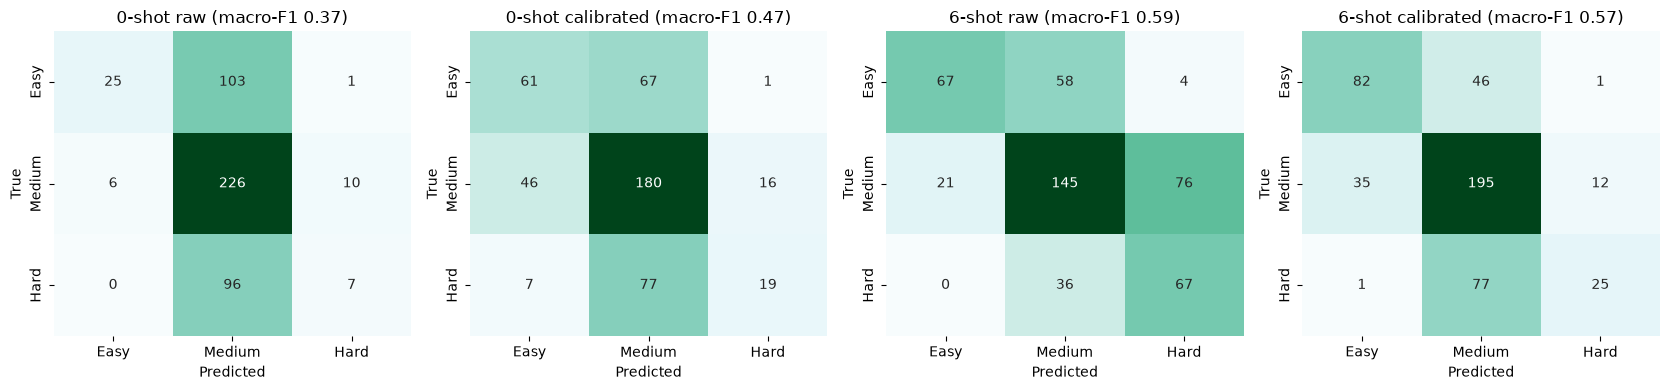

best variant (by calibration-set macro-F1): 6-shot raw


In [ ]:
fig, axes = plt.subplots(1, len(preds), figsize=(4.2 * len(preds), 4), squeeze=False)
for ax, (name, Pt) in zip(axes[0], preds.items()):
    cm = pd.crosstab(y_test, Pt.argmax(1)).reindex(index=[0, 1, 2], columns=[0, 1, 2]).fillna(0).astype(int).values
    sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn", xticklabels=LABELS, yticklabels=LABELS, cbar=False, ax=ax)
    ax.set_title(f"{name} (macro-F1 {table.loc[name, 'test_macro_f1']:.2f})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.tight_layout()
fig.savefig(CFG.figures_dir / f"{MODEL_NAME}.png", dpi=CFG.fig_dpi)
plt.show()

best = table["calib_macro_f1"].idxmax()        # chosen on training problems, not on the test set
print("best variant (by calibration-set macro-F1):", best)

## 5. Log to MLflow

One run per variant: `llama-llama3.1-8b-<n>shot-s<seed>` in experiment `.../llama`, with raw and calibrated test
scores, both confusion matrices and the prompt settings.

In [ ]:
for k, (P_calib, P_test, mass) in scores.items():
    raw, cal = table.loc[f"{3 * k}-shot raw"], table.loc[f"{3 * k}-shot calibrated"]
    with start_run("llama", MODEL_NAME, f"{3 * k}shot", job_type="eval", config={
            "model": MODEL, "shots_per_class": k, "examples": [slugs[example_idx[c][j]] for j in range(k) for c in range(3)],
            "calibration_problems": len(calib_idx), "system_prompt": SYSTEM, "scoring": "next-token probabilities"}) as run:
        log_classification(run, y_test, preds[f"{3 * k}-shot raw"].argmax(1), prefix="test/raw")
        log_classification(run, y_test, preds[f"{3 * k}-shot calibrated"].argmax(1), prefix="test/calibrated")
        run.summary.update({"label_mass": mass, "calibration/T": float(cal["T"]),
                            "calib/macro_f1": float(cal["calib_macro_f1"]),
                            "test/raw/log_loss": float(raw["test_log_loss"]), "test/raw/ece": float(raw["test_ece"]),
                            "test/calibrated/log_loss": float(cal["test_log_loss"]), "test/calibrated/ece": float(cal["test_ece"])})
        log_image(run, "confusion_matrices", CFG.figures_dir / f"{MODEL_NAME}.png")

test/raw: accuracy 0.544, macro_f1 0.369, qwk 0.217
test/calibrated: accuracy 0.549, macro_f1 0.470, qwk 0.363
test/raw: accuracy 0.589, macro_f1 0.585, qwk 0.563
test/calibrated: accuracy 0.637, macro_f1 0.572, qwk 0.531


# Extras

Three follow-up experiments on top of the main result. They reuse everything above (model, scores, calibration),
so run sections 1–5 first; each extra builds on the previous one.

## Extra 1 · Tuning the Easy/Hard bias for macro-F1

**Why.** The calibration in section 4 makes the probabilities *honest* (it minimises log-loss), not the macro-F1.
The model then plays safe: most Hard problems end up as Medium.

**How.** Add an extra log-bias for Easy and one for Hard (Medium stays 0), try every pair on a grid from −1 to 3,
and keep the pair with the best macro-F1 on the 600 calibration problems (training part). The test set is used
once, afterwards.

**Output.** The chosen bias, test scores before/after, both confusion matrices
(`confusion_matrices/llama3.1-8b_f1tuned.png`) and the MLflow run `llama-llama3.1-8b-<n>shot-f1tuned-s<seed>`.

bias shift (Easy, Medium, Hard) = [-0.3  0.   0.4], calibration-set macro-F1 0.626
6-shot calibrated (test): accuracy 0.637, macro_f1 0.572, qwk 0.531
6-shot F1-tuned (test): accuracy 0.648, macro_f1 0.617, qwk 0.577


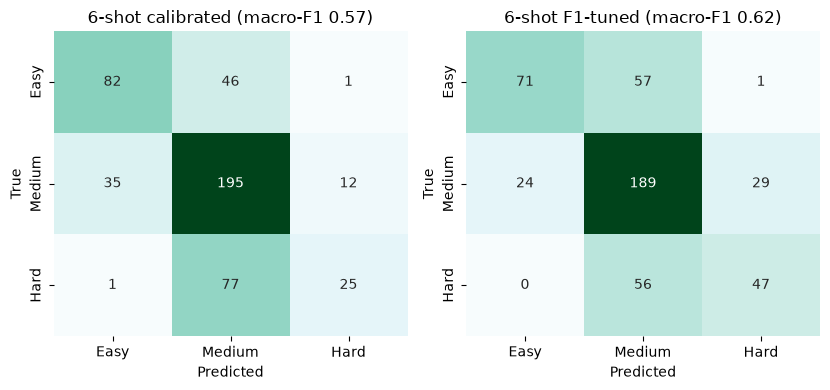

test/f1tuned: accuracy 0.648, macro_f1 0.617, qwk 0.577


In [ ]:
k_best = int(table.loc[best, "shots"]) // 3                  # shots count of the best variant
P_calib, P_test, _ = scores[k_best]
cal, _, _ = fit_temp_bias(P_calib, y_calib)
L_calib, L_test = np.log(cal(P_calib)), np.log(cal(P_test))  # calibrated log-probabilities

# try extra log-bias for Easy and Hard (Medium stays 0) and keep the pair with the best macro-F1
grid = np.linspace(-1, 3, 41)
best_f1, shift = -1.0, np.zeros(3)
for b_easy in grid:
    for b_hard in grid:
        s = np.array([b_easy, 0.0, b_hard])
        f1 = f1_score(y_calib, (L_calib + s).argmax(1), average="macro")
        if f1 > best_f1 + 1e-9:
            best_f1, shift = f1, s
print(f"bias shift (Easy, Medium, Hard) = {shift.round(2)}, calibration-set macro-F1 {best_f1:.3f}")

pred_calibrated = L_test.argmax(1)
pred_tuned = (L_test + shift).argmax(1)
m_before = report(y_test, pred_calibrated, name=f"{3 * k_best}-shot calibrated (test)")
m_after = report(y_test, pred_tuned, name=f"{3 * k_best}-shot F1-tuned (test)")

fig, axes = plt.subplots(1, 2, figsize=(8.4, 4))
for ax, (title, pred, m) in zip(axes, [("calibrated", pred_calibrated, m_before), ("F1-tuned", pred_tuned, m_after)]):
    cm = pd.crosstab(y_test, pred).reindex(index=[0, 1, 2], columns=[0, 1, 2]).fillna(0).astype(int).values
    sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn", xticklabels=LABELS, yticklabels=LABELS, cbar=False, ax=ax)
    ax.set_title(f"{3 * k_best}-shot {title} (macro-F1 {m['macro_f1']:.2f})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.tight_layout()
fig.savefig(CFG.figures_dir / f"{MODEL_NAME}_f1tuned.png", dpi=CFG.fig_dpi)
plt.show()

with start_run("llama", MODEL_NAME, f"{3 * k_best}shot-f1tuned", job_type="eval", config={
        "model": MODEL, "shots_per_class": k_best, "bias_shift": shift.round(3).tolist(),
        "tuned_on": f"{len(calib_idx)} calibration problems (training part)"}) as run:
    log_classification(run, y_test, pred_tuned, prefix="test/f1tuned")
    run.summary.update({"calib/macro_f1": best_f1})

## Extra 2 · Contamination check: difficulty from the title alone

**Why.** Llama 3.1 was trained on web data up to December 2023, and every problem in the dataset, together with
its Easy/Medium/Hard label, is on the web. Part of its score may be *remembering* labels instead of reading the
statement.

**How.** Same scorer and calibration, but the examples and the question show only the title (e.g. "House
Robber II"). As a control, TF-IDF + logistic regression on the same titles: it cannot remember anything, so it
shows how much the title words alone give away.

**How to read it (macro-F1)**

| Llama on the title only is… | meaning |
|---|---|
| close to its full-statement score | mostly memory |
| about the TF-IDF-on-titles score | the title words give that much away; no sign of memory |
| clearly in between | partly memory, partly reading the statement |

The gap to TF-IDF is an upper bound on memory: Llama also *understands* titles ("Minimum Cost to Merge Stones"
suggests dynamic programming) without having seen the problem. **Output:** `results/llama3.1-8b_title_check.csv`
and the MLflow run `llama-llama3.1-8b-title-check-s<seed>`.

In [ ]:
titles = [re.sub(r"\b(Ii|Iii|Iv|Vi|Vii)\b", lambda m: m.group(0).upper(), s.replace("-", " ").title()) for s in slugs]


@contextmanager
def title_mode():
    # while active, the prompt examples and the question are titles only (messages()/user_turn() read these globals)
    global problems, user_turn
    saved = problems, user_turn
    problems = titles
    user_turn = lambda title: {"role": "user", "content": f"Problem title: {title}\n\nDifficulty?"}
    try:
        yield
    finally:
        problems, user_turn = saved


def cached_probs(path, keys, items, k, as_title, desc):
    # probabilities for items[i] (keyed by keys[i]); results are appended to `path`, so a stopped run resumes
    done = {}
    if path.exists():
        for line in open(path):
            r = json.loads(line); done[r["slug"]] = r
    todo = [i for i in range(len(keys)) if str(keys[i]) not in done]
    if todo:
        with (title_mode() if as_title else nullcontext()):
            scorer = DifficultyScorer(k)
            with open(path, "a") as f:
                for i in tqdm(todo, desc=desc):
                    p, mass = scorer(items[i])
                    r = {"slug": str(keys[i]), "p": p.tolist(), "label_mass": mass}
                    done[r["slug"]] = r
                    f.write(json.dumps(r) + "\n")
    a = np.array([done[str(key)]["p"] for key in keys])
    return a / a.sum(1, keepdims=True)


def score_titles(k):
    # calibration + test problems, titles only; separate cache file
    idx = np.concatenate([calib_idx, test_idx])
    P = cached_probs(OUT / f"{MODEL_NAME}_{3 * k}shot_titles.jsonl", slugs[idx], [titles[i] for i in idx],
                     k, as_title=True, desc=f"{3 * k}-shot, titles only")
    return P[:len(calib_idx)], P[len(calib_idx):]


title_rows = []
for k in SHOTS_PER_CLASS:
    P_calib_full, P_test_full, _ = scores[k]
    cal_full, _, _ = fit_temp_bias(P_calib_full, y_calib)
    P_calib_t, P_test_t = score_titles(k)
    cal_t, _, _ = fit_temp_bias(P_calib_t, y_calib)
    title_rows.append({"input": f"Llama {3 * k}-shot, full statement",
                       **report(y_test, cal_full(P_test_full).argmax(1), name=f"{3 * k}-shot full")})
    title_rows.append({"input": f"Llama {3 * k}-shot, title only",
                       **report(y_test, cal_t(P_test_t).argmax(1), name=f"{3 * k}-shot title")})

# control: a model that can only use the words of the title, no memory of LeetCode
title_arr = np.array(titles)
tfidf_titles = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True),
                             LogisticRegression(class_weight="balanced", max_iter=2000))
tfidf_titles.fit(title_arr[train_idx], y[train_idx])
title_rows.append({"input": "TF-IDF + logistic regression, title only (no memory)",
                   **report(y_test, tfidf_titles.predict(title_arr[test_idx]), name="TF-IDF title")})

contamination = pd.DataFrame(title_rows).set_index("input")
contamination.to_csv(CFG.results_dir / f"{MODEL_NAME}_title_check.csv", float_format="%.4f")

with start_run("llama", MODEL_NAME, "title-check", job_type="eval", config={
        "model": MODEL, "question": "difficulty from the problem title alone"}) as run:
    for name, r in contamination.iterrows():
        run.summary.update({f"{name}/{key}": float(v) for key, v in r.items()})

print("\nalways Medium: macro-F1 0.225, QWK 0.00")
contamination

0-shot, titles only: 100%|██████████| 1074/1074 [04:18<00:00,  4.16it/s]


0-shot full: accuracy 0.549, macro_f1 0.470, qwk 0.363
0-shot title: accuracy 0.582, macro_f1 0.493, qwk 0.396


6-shot, titles only: 100%|██████████| 1074/1074 [04:05<00:00,  4.37it/s]

6-shot full: accuracy 0.637, macro_f1 0.572, qwk 0.531
6-shot title: accuracy 0.616, macro_f1 0.539, qwk 0.462
tfidf title: accuracy 0.401, macro_f1 0.380, qwk 0.144

always Medium: macro-F1 0.225, QWK 0.00


,accuracy,macro_f1,qwk
input,,,
"Llama 0-shot, full statement",0.548523,0.470494,0.362687
"Llama 0-shot, title only",0.582278,0.493224,0.395950
"Llama 6-shot, full statement",0.637131,0.571669,0.530620
"Llama 6-shot, title only",0.616034,0.539405,0.461563
"TF-IDF + logistic regression, title only (no memory)",0.400844,0.379889,0.143788


## Extra 3 · Problems published after the training cut-off

Extra 2 hints at memorisation: from the title alone Llama keeps most of its score, far above what the title words
explain. Llama 3.1's training data ends in December 2023, so the real test is problems LeetCode published
**afterwards**: the model cannot have seen them.

**How.**
1. `python data/fetch_new_problems.py` downloads the free problems with ID ≥ 3000 (≈ January 2024 onwards) into
   `data/leetcode_new_problems.json`.
2. They are scored with the same prompts, and with the calibration and Easy/Hard bias learned on the old training
   problems. Nothing is refitted on the new problems.
3. Control: TF-IDF + logistic regression trained on the old training part (full statements). It has no memory, so
   its drop from old to new problems only shows that newer problems look different.

**How to read it (`drop_macro_f1` = old test − new problems)**

| What you see | meaning |
|---|---|
| Llama drops about as much as the control | newer problems are just different; Llama really reads difficulty |
| Llama drops much more than the control | the extra drop is what it had memorised |
| Llama's title-only score collapses on new problems | confirms that Extra 2's title result was memory |

**Output.** `results/llama3.1-8b_new_problems.csv`, `confusion_matrices/llama3.1-8b_new_problems.png` and the MLflow
run `llama-llama3.1-8b-new-problems-s<seed>`.

In [ ]:
assert NEW_DATASET_PATH.exists(), "run `python data/fetch_new_problems.py` first"
new_raw = json.load(open(NEW_DATASET_PATH))
new_slugs, new_texts, y_new = load_problems(path=NEW_DATASET_PATH)
new_problems = [compact_statement(t) for t in new_texts]
new_titles = [new_raw[s]["title"] for s in new_slugs]
new_ids = [new_raw[s]["frontend_id"] for s in new_slugs]
print(f"{len(y_new)} new problems, IDs {min(new_ids)}-{max(new_ids)}, Easy/Medium/Hard = {np.bincount(y_new, minlength=3)}")


def score_new(k, as_title=False):
    suffix = "_titles" if as_title else ""
    return cached_probs(OUT / f"{MODEL_NAME}_new_{3 * k}shot{suffix}.jsonl", new_slugs,
                        new_titles if as_title else new_problems, k, as_title,
                        desc=f"new problems, {3 * k}-shot{', titles' if as_title else ''}")


unseen_rows, pred_new_best = [], None
for k in SHOTS_PER_CLASS:
    P_calib_k, P_test_k, _ = scores[k]
    cal_k, _, _ = fit_temp_bias(P_calib_k, y_calib)
    P_calib_t, P_test_t = score_titles(k)                     # cached by Extra 2
    cal_t, _, _ = fit_temp_bias(P_calib_t, y_calib)
    P_new, P_new_t = score_new(k), score_new(k, as_title=True)

    variants = [(f"Llama {3 * k}-shot calibrated", cal_k(P_test_k), cal_k(P_new)),
                (f"Llama {3 * k}-shot calibrated, title only", cal_t(P_test_t), cal_t(P_new_t))]
    if k == k_best:                                           # + the Easy/Hard shift from Extra 1
        tuned = lambda P: np.exp(np.log(cal_k(P)) + shift)
        variants.append((f"Llama {3 * k}-shot F1-tuned", tuned(P_test_k), tuned(P_new)))
        pred_new_best = tuned(P_new).argmax(1)
    for name, P_old, P_nw in variants:
        old_m = report(y_test, P_old.argmax(1), name=f"{name} | old test")
        new_m = report(y_new, P_nw.argmax(1), name=f"{name} | NEW")
        unseen_rows.append({"model": name, "old_test_macro_f1": old_m["macro_f1"], "new_macro_f1": new_m["macro_f1"],
                            "old_test_qwk": old_m["qwk"], "new_qwk": new_m["qwk"], "new_accuracy": new_m["accuracy"]})

# control without memory, trained on the old training part (full statements)
problems_arr = np.array(problems, dtype=object)
control = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True),
                        LogisticRegression(class_weight="balanced", max_iter=2000))
control.fit(problems_arr[train_idx], y[train_idx])
old_m = report(y_test, control.predict(problems_arr[test_idx]), name="TF-IDF control | old test")
new_m = report(y_new, control.predict(np.array(new_problems, dtype=object)), name="TF-IDF control | NEW")
unseen_rows.append({"model": "TF-IDF + logistic regression (no memory)", "old_test_macro_f1": old_m["macro_f1"],
                    "new_macro_f1": new_m["macro_f1"], "old_test_qwk": old_m["qwk"], "new_qwk": new_m["qwk"],
                    "new_accuracy": new_m["accuracy"]})

unseen = pd.DataFrame(unseen_rows).set_index("model")
unseen["drop_macro_f1"] = unseen["old_test_macro_f1"] - unseen["new_macro_f1"]
unseen.to_csv(CFG.results_dir / f"{MODEL_NAME}_new_problems.csv", float_format="%.4f")
unseen

In [ ]:
cm = pd.crosstab(y_new, pred_new_best).reindex(index=[0, 1, 2], columns=[0, 1, 2]).fillna(0).astype(int).values
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn", xticklabels=LABELS, yticklabels=LABELS, cbar=False)
plt.title(f"{3 * k_best}-shot F1-tuned, NEW problems (macro-F1 {f1_score(y_new, pred_new_best, average='macro'):.2f})")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout()
plt.savefig(CFG.figures_dir / f"{MODEL_NAME}_new_problems.png", dpi=CFG.fig_dpi)
plt.show()

with start_run("llama", MODEL_NAME, "new-problems", job_type="eval", config={
        "model": MODEL, "new_problems": len(y_new), "id_range": f"{min(new_ids)}-{max(new_ids)}"}) as run:
    log_classification(run, y_new, pred_new_best, prefix="new/f1tuned")
    for name, r in unseen.iterrows():
        run.summary.update({f"{name}/{c}": float(v) for c, v in r.items()})
    log_image(run, "confusion_matrix_new", CFG.figures_dir / f"{MODEL_NAME}_new_problems.png")